# 01 — Audit initial des données SpamGuard-FR

## 1. Objectif et origine du dataset

Ce notebook décrit le corpus avant toute séparation train/test et avant tout entraînement. Il s'appuie sur le **SMS Spam Multilingual Collection Dataset** disponible sur Hugging Face, dérivé du **SMS Spam Collection** publié par UCI (DOI `10.24432/C5CC84`).

Le texte français est issu d'une **traduction automatique** du corpus anglais : il ne s'agit pas de SMS natifs collectés en France.

In [1]:
from io import BytesIO
from pathlib import Path
import os
import sys

candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(path for path in candidates if (path / 'config' / 'config.yaml').exists())
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Image, Markdown

from spamguard.audit import run_audit
from spamguard.data import load_processed_data, prepare_dataset
from spamguard.features import add_exploratory_features

RANDOM_SEED = 42
processed_path = prepare_dataset()
df = load_processed_data(processed_path)
features = add_exploratory_features(df)
print(f"Dataset préparé : {processed_path.relative_to(PROJECT_ROOT)}")

Dataset préparé : data/processed/sms_fr.csv


## 2. Dimensions et qualité générale

Cette première vérification résume la taille du corpus, les deux classes, les valeurs manquantes et les doublons exacts.

In [2]:
exact_duplicates = int(df.duplicated(['label', 'text_fr', 'text_en']).sum())
quality_summary = pd.DataFrame({
    'indicateur': [
        'Nombre de lignes',
        'Nombre de colonnes',
        'Valeurs manquantes (total)',
        'Doublons exacts (hors identifiant)',
    ],
    'valeur': [len(df), df.shape[1], int(df.isna().sum().sum()), exact_duplicates],
})
display(quality_summary)
display(Markdown('**Labels :**\n- `ham` = SMS normal / légitime\n- `spam` = SMS indésirable'))
display(df.isna().sum().to_frame('valeurs manquantes'))

,indicateur,valeur
0,Nombre de lignes,5572
1,Nombre de colonnes,4
2,Valeurs manquantes (total),0
3,Doublons exacts (hors identifiant),415


**Labels :**
- `ham` = SMS normal / légitime
- `spam` = SMS indésirable

,valeurs manquantes
id,0
label,0
text_fr,0
text_en,0


## 3. Distribution des classes

Le tableau donne le nombre et le pourcentage de messages pour chaque classe.

,nombre,pourcentage (%)
label,,
ham,4825,86.59
spam,747,13.41


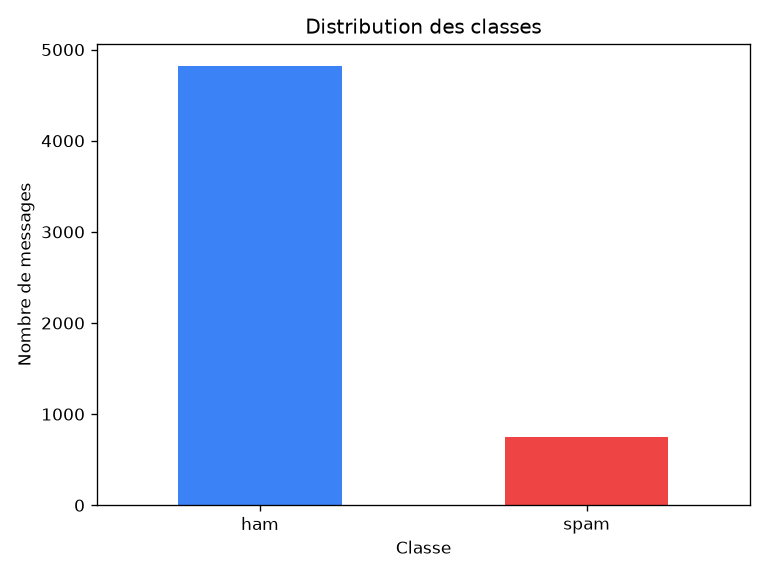

In [3]:
class_counts = df['label'].value_counts().reindex(['ham', 'spam'])
class_distribution = pd.DataFrame({
    'nombre': class_counts,
    'pourcentage (%)': (class_counts / len(df) * 100).round(2),
})
display(class_distribution)

ax = class_counts.plot.bar(
    color=['#3b82f6', '#ef4444'],
    rot=0,
    title='Distribution des classes',
)
ax.set(xlabel='Classe', ylabel='Nombre de messages')
ax.figure.tight_layout()
image_buffer = BytesIO()
ax.figure.savefig(image_buffer, format='png', dpi=120)
plt.close(ax.figure)
display(Image(data=image_buffer.getvalue()))

> **Le dataset est déséquilibré : la classe ham est largement majoritaire. L'accuracy seule ne sera donc pas suffisante pour évaluer les modèles.**

## 4. Quelques exemples ham / spam

Une analyse exploratoire complémentaire montre quelques différences de forme entre ham et spam, mais ces indicateurs ne sont pas utilisés pour entraîner le modèle final.

In [4]:
example_groups = [
    ('ham', 'SMS légitimes'),
    ('spam', 'SMS indésirables'),
]

for label, description in example_groups:
    texts = (
        df.loc[df['label'] == label, 'text_fr']
          .sample(n=3, random_state=RANDOM_SEED)
          .tolist()
    )
    lines = [f'### Exemples {label} — {description}', '']
    lines.extend(
        f'{number}. {text.replace(chr(10), " ")}'
        for number, text in enumerate(texts, start=1)
    )
    display(Markdown('\n'.join(lines)))

### Exemples ham — SMS légitimes

1. Si je ne rencontre pas tous les rites, je rentrerai chez moi.
2. Je serai toujours là, même si c'est juste dans l'esprit. J'aurai bientôt un bb. J'essaie juste d'être sûr que j'en ai besoin.
3. Désolé que ça ait pris si longtemps, omw maintenant

### Exemples spam — SMS indésirables

1. Summers enfin ici! Fantastique un chat ou flirt avec des singles sexy dans la région de l'an? Pour obtenir MATCHED juste répondez SUMMER maintenant. Gratuit 2 Rejoignez. OptOut txt STOP Help08714742804
2. C'est la 2ème fois que nous avons essayé 2 contact u. U ont gagné le prix 750 Pound. 2 réclamation est facile, appelez 08718726970 MAINTENANT! Seulement 10p par min. BT-national-rate
3. Get ur 1st RINGTONE GRATUITEMENT! Répondre à ce msg avec TONE. Gr8 TOP 20 tons à votre téléphone chaque semaine juste £1.50 par wk 2 opt out envoyer STOP 08452810071 16

## 5. Limites de la traduction française

- Le corpus français provient d'une **traduction automatique**.
- Il ne contient pas des SMS natifs collectés en France.
- Des formulations, monnaies et références britanniques ou anglophones restent visibles.

L'échantillon bilingue ci-dessous sert à constater ces limites qualitativement, sans attribuer une note automatique à la traduction.

In [5]:
translation_sample = (
    df.groupby('label', group_keys=False)
      .sample(n=3, random_state=RANDOM_SEED)
      .reset_index(drop=True)
)
display(translation_sample[['label', 'text_en', 'text_fr']])

observable_markers = pd.Series({
    'Monnaie britannique (£ ou livre)': df['text_fr'].str.contains(
        r'£|\blivres?\b', case=False, regex=True, na=False
    ).sum(),
    'Référence anglophone indicative': df['text_fr'].str.contains(
        r'£|\bpounds?\b|\buk\b|london|wimbledon|nokia|orange',
        case=False,
        regex=True,
        na=False,
    ).sum(),
})
display(observable_markers.to_frame('nombre de messages'))
print("Ces marqueurs orientent l'inspection humaine ; ils ne mesurent pas la qualité de traduction.")

,label,text_en,text_fr
0,ham,If i not meeting ü all rite then i'll go home ...,"Si je ne rencontre pas tous les rites, je rent..."
1,ham,"I.ll always be there, even if its just in spir...","Je serai toujours là, même si c'est juste dans..."
2,ham,"Sorry that took so long, omw now","Désolé que ça ait pris si longtemps, omw maint..."
3,spam,Today's Offer! Claim ur £150 worth of discount...,Offre d'aujourd'hui! Réclamez une valeur de £1...
4,spam,Buy Space Invaders 4 a chance 2 win orig Arcad...,Acheter Space Invaders 4 une chance 2 win orig...
5,spam,FreeMsg: Txt: CALL to No: 86888 & claim your r...,FreeMsg: Txt: CALL to No: 86888 & réclamer vot...


,nombre de messages
Monnaie britannique (£ ou livre),288
Référence anglophone indicative,363


Ces marqueurs orientent l'inspection humaine ; ils ne mesurent pas la qualité de traduction.


## 6. Doublons et risque de data leakage

> **Un même message présent dans le train et dans le test pourrait artificiellement améliorer les performances du modèle. Les doublons doivent donc être gérés avant la séparation train/test.**

Aucun split n'est réalisé dans ce notebook. Les statistiques suivantes distinguent les répétitions du texte français et du texte anglais.

In [6]:
def duplicate_report(column):
    sizes = df.groupby(column, dropna=False).size()
    conflicts = df.groupby(column, dropna=False)['label'].nunique()
    return {
        'groupes dupliqués': int((sizes > 1).sum()),
        'lignes excédentaires': int((sizes - 1).clip(lower=0).sum()),
        'textes avec labels différents': int((conflicts > 1).sum()),
    }

leakage_report = pd.DataFrame({
    'français': duplicate_report('text_fr'),
    'anglais': duplicate_report('text_en'),
})
display(leakage_report)
print(f'Doublons exacts français + anglais + label (hors id) : {exact_duplicates}')

,français,anglais
groupes dupliqués,295,289
lignes excédentaires,438,415
textes avec labels différents,0,0


Doublons exacts français + anglais + label (hors id) : 415


## 7. Choix des futures métriques

Le déséquilibre des classes impose de lire plusieurs métriques ensemble :

- **Accuracy** : proportion totale de prédictions correctes ;
- **Precision spam** : parmi les messages classés spam, proportion de vrais spams ;
- **Recall spam** : parmi les vrais spams, proportion correctement détectée ;
- **F1-score spam** : compromis entre precision et recall ;
- **Matrice de confusion** : détail des prédictions correctes et des deux types d'erreurs.

Un **faux positif** est un SMS légitime classé spam. Un **faux négatif** est un spam classé comme légitime.

## 8. Génération du rapport automatique

Les résultats détaillés sont enregistrés dans :

- `outputs/reports/data_audit.json`
- `outputs/reports/data_audit.md`

In [7]:
audit = run_audit()
display(pd.DataFrame(audit['label_distribution']).T)
print('Rapports écrits :')
print('- outputs/reports/data_audit.json')
print('- outputs/reports/data_audit.md')
print('Aucun modèle entraîné ; aucun split réalisé.')

,count,percentage
ham,4825.0,86.59
spam,747.0,13.41


Rapports écrits :
- outputs/reports/data_audit.json
- outputs/reports/data_audit.md
Aucun modèle entraîné ; aucun split réalisé.
